C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

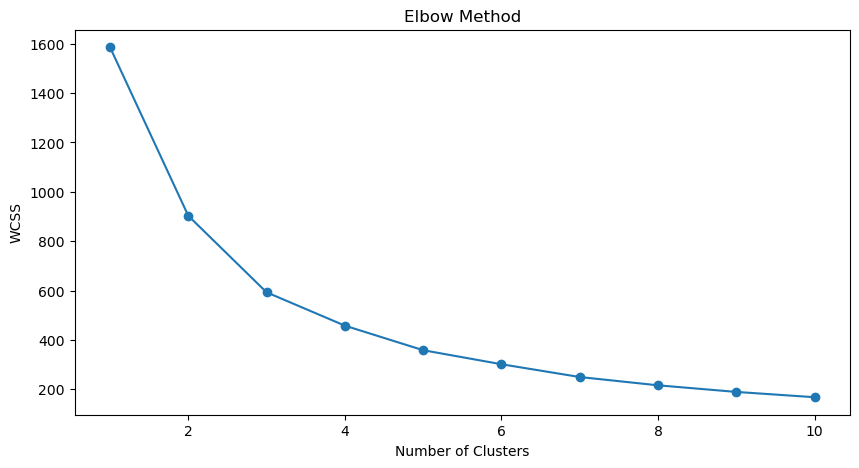

     Customer_Name  Total_Sales  Total_Orders  Cluster
0    Aaron Bergman      283.316             3        1
1    Aaron Hawkins     1039.728             7        3
2   Aaron Smayling     2969.890             7        3
3  Adam Bellavance     2323.136             8        0
4        Adam Hart     1906.337            10        0

Cluster Summary:

         Total_Sales  Total_Orders
Cluster                           
0        1895.371388      9.788820
1         488.530672      3.755172
2        6108.734979      7.230769
3        1313.008139      6.518152


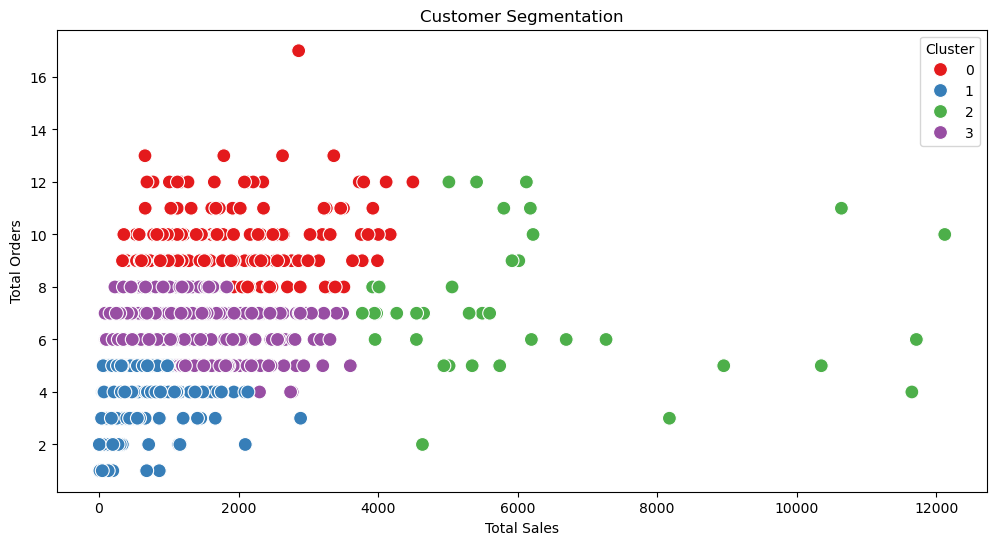


Customer Segmentation Completed Successfully.


In [2]:
# ============================================================
# CUSTOMER SEGMENTATION USING K-MEANS CLUSTERING
# ============================================================

# ======================
# IMPORT LIBRARIES
# ======================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ======================
# LOAD DATASET
# ======================

df = pd.read_csv("eda_final_superstore.csv") # Corrected filename from 'eda_final_superstore(1).csv'

# ======================
# CREATE CUSTOMER FEATURES
# ======================

# Removed 'Profit', 'Quantity', 'Discount' as they were not found in df.columns.tolist()
customer_data = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Order ID": "count" # Using Order ID count as a proxy for Total_Orders
}).reset_index()

# Rename columns
customer_data.columns = [
    "Customer_Name",
    "Total_Sales",
    "Total_Orders"
]

# ======================
# SELECT FEATURES
# ======================

X = customer_data[[
    "Total_Sales",
    "Total_Orders"
]]

# ======================
# FEATURE SCALING
# ======================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ======================
# FIND OPTIMAL CLUSTERS
# ELBOW METHOD
# ======================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph

plt.figure(figsize=(10,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# ======================
# TRAIN K-MEANS MODEL
# ======================

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)

customer_data['Cluster'] = kmeans.fit_predict(X_scaled)

# ======================
# VIEW CLUSTERS
# ======================

print(customer_data.head())

# ======================
# CLUSTER SUMMARY
# ======================

cluster_summary = customer_data.groupby("Cluster").mean(numeric_only=True)

print("\nCluster Summary:\n")
print(cluster_summary)

# ======================
# VISUALIZE CLUSTERS
# ======================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=customer_data,
    x='Total_Sales',
    y='Total_Orders', # Changed from Total_Profit as it was not present
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("Total Sales")
plt.ylabel("Total Orders") # Changed from Total Profit

plt.show()

# ======================
# SAVE OUTPUT
# ======================

customer_data.to_csv(
    "customer_segments.csv",
    index=False
)

print("\nCustomer Segmentation Completed Successfully.")